# Projeto Avaliativo — Machine Learning e Visão Computacional

## Previsão de Risco de Crédito

O objetivo deste projeto é desenvolver um pipeline preditivo capaz de identificar
clientes com risco de inadimplência.

A variável alvo utilizada será `loan_status`, onde:

- `0` = cliente sem inadimplência
- `1` = cliente inadimplente

O projeto será dividido em etapas de análise exploratória, tratamento de dados,
engenharia de atributos, preparação dos dados, treinamento dos modelos KNN e
Árvore de Decisão e avaliação dos resultados.

# 1. Preparação do Ambiente

## 1.1 Importação das Bibliotecas

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os


print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


## 1.2 Definição do Diretório do Projeto

In [3]:
os.chdir(r"C:\Users\Alisson\Desktop\Alisson\sctec\Projeto-risco-credito")

## 1.3 Carregamento da Base de Dados

In [4]:
df = pd.read_csv("data/credit_risk_dataset.csv")

df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


# 2. Análise Exploratória de Dados (EDA)

Nesta etapa serão analisadas as dimensões da base, os tipos das variáveis, estatísticas descritivas, valores ausentes, distribuição da variável alvo e possíveis outliers.

## 2.1 Dimensões da Base

In [5]:
print("Linhas:", df.shape[0])
print("Colunas:", df.shape[1])

Linhas: 32581
Colunas: 12


## 2.2 Tipos de Dados e Valores Não Nulos

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  str    
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  str    
 5   loan_grade                  32581 non-null  str    
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  str    
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 3.0 MB


## 2.3 Estatísticas Descritivas

In [7]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


## 2.4 Análise de Valores Ausentes

Nesta etapa serão identificadas as colunas que possuem valores nulos e a quantidade de registros ausentes em cada uma delas.

A análise dos valores ausentes é importante para definir posteriormente a estratégia de imputação mais adequada, utilizando média ou mediana conforme a distribuição dos dados e a presença de outliers.

In [8]:
valores_nulos = df.isnull().sum()

valores_nulos[valores_nulos > 0]

person_emp_length     895
loan_int_rate        3116
dtype: int64

In [9]:
percentual_nulos = (df.isnull().sum() / len(df)) * 100

percentual_nulos[percentual_nulos > 0]

person_emp_length    2.747000
loan_int_rate        9.563856
dtype: float64

### Análise dos Valores Ausentes

Foram identificados valores ausentes em duas variáveis:

- `person_emp_length`: 895 valores ausentes, aproximadamente 2,75% da base.
- `loan_int_rate`: 3.116 valores ausentes, aproximadamente 9,56% da base.

Esses valores serão analisados posteriormente para definir a técnica de imputação mais adequada, considerando a distribuição dos dados e a influência de possíveis outliers.

## 2.5 Distribuição da Variável Alvo

A variável alvo do projeto é `loan_status`, onde:

- `0` representa clientes adimplentes.
- `1` representa clientes inadimplentes.

Nesta etapa será analisada a proporção entre as classes para verificar a existência de desbalanceamento na base.

In [10]:
contagem_classes = df["loan_status"].value_counts()
percentual_classes = df["loan_status"].value_counts(normalize=True) * 100

print("Quantidade por classe:")
display(contagem_classes)

print("\nPercentual por classe:")
display(percentual_classes)

Quantidade por classe:


loan_status
0    25473
1     7108
Name: count, dtype: int64


Percentual por classe:


loan_status
0    78.183604
1    21.816396
Name: proportion, dtype: float64

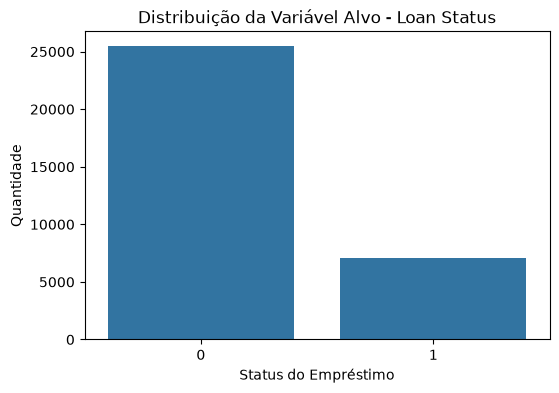

In [11]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="loan_status")

plt.title("Distribuição da Variável Alvo - Loan Status")
plt.xlabel("Status do Empréstimo")
plt.ylabel("Quantidade")

plt.show()

### Análise da Variável Alvo

A variável `loan_status` apresenta desbalanceamento entre as classes.

A classe `0`, referente aos clientes adimplentes, possui 25.473 registros e representa aproximadamente 78,18% da base.

A classe `1`, referente aos clientes inadimplentes, possui 7.108 registros e representa aproximadamente 21,82% da base.

Essa diferença evidencia o desbalanceamento da variável alvo. Na etapa de preparação dos dados, será aplicada uma técnica de balanceamento apenas sobre o conjunto de treino, evitando vazamento de dados para o conjunto de teste.

## 2.6 Análise de Outliers

Nesta etapa serão analisados possíveis valores discrepantes nas variáveis numéricas.

A identificação de outliers é especialmente importante porque o modelo KNN é sensível a valores extremos, já que utiliza medidas de distância entre os registros. Já a Árvore de Decisão tende a ser mais robusta a esse tipo de situação.

Por isso, os valores discrepantes não serão removidos automaticamente. Primeiro será avaliado se representam observações plausíveis ou inconsistências nos dados.

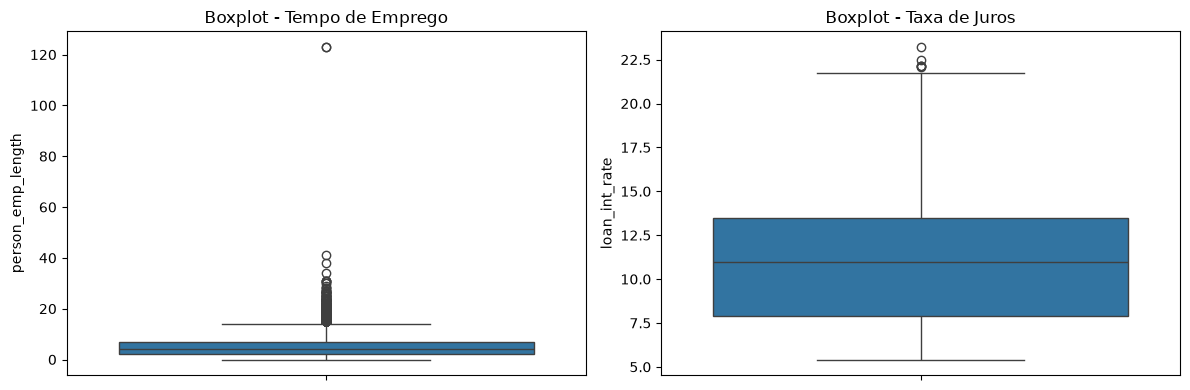

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(y=df["person_emp_length"], ax=axes[0])
axes[0].set_title("Boxplot - Tempo de Emprego")

sns.boxplot(y=df["loan_int_rate"], ax=axes[1])
axes[1].set_title("Boxplot - Taxa de Juros")

plt.tight_layout()
plt.show()

In [13]:
df.sort_values("person_emp_length", ascending=False)[
    ["person_age", "person_emp_length"]
].head(15)

,person_age,person_emp_length
210,21,123.0
0,22,123.0
32355,78,41.0
32515,53,38.0
32428,58,34.0
31866,47,31.0
30914,48,31.0
31867,46,31.0
32263,46,31.0
32539,61,30.0


### Análise dos Outliers

A variável `person_emp_length` apresentou diversos valores acima do limite superior do boxplot.

Ao analisar os maiores registros, foram encontrados dois casos em que o tempo de emprego é igual a 123 anos para clientes de 21 e 22 anos. Esses valores são logicamente impossíveis e indicam inconsistência nos dados.

Por outro lado, outros valores elevados de tempo de emprego, como 30, 31, 38 e 41 anos, podem ser plausíveis dependendo da idade do cliente e, por isso, não serão removidos automaticamente.

Na variável `loan_int_rate`, foram observados alguns valores acima do limite superior do boxplot, porém eles permanecem dentro de uma faixa possível para taxas de juros. Portanto, esses registros serão mantidos.

As inconsistências identificadas em `person_emp_length` serão tratadas na etapa de limpeza dos dados.

## 2.7 Análise de Correlação

Nesta etapa será analisada a correlação entre as variáveis numéricas da base.

A matriz de correlação ajuda a identificar relações lineares entre os atributos e a variável alvo, além de possíveis relações fortes entre variáveis preditoras.

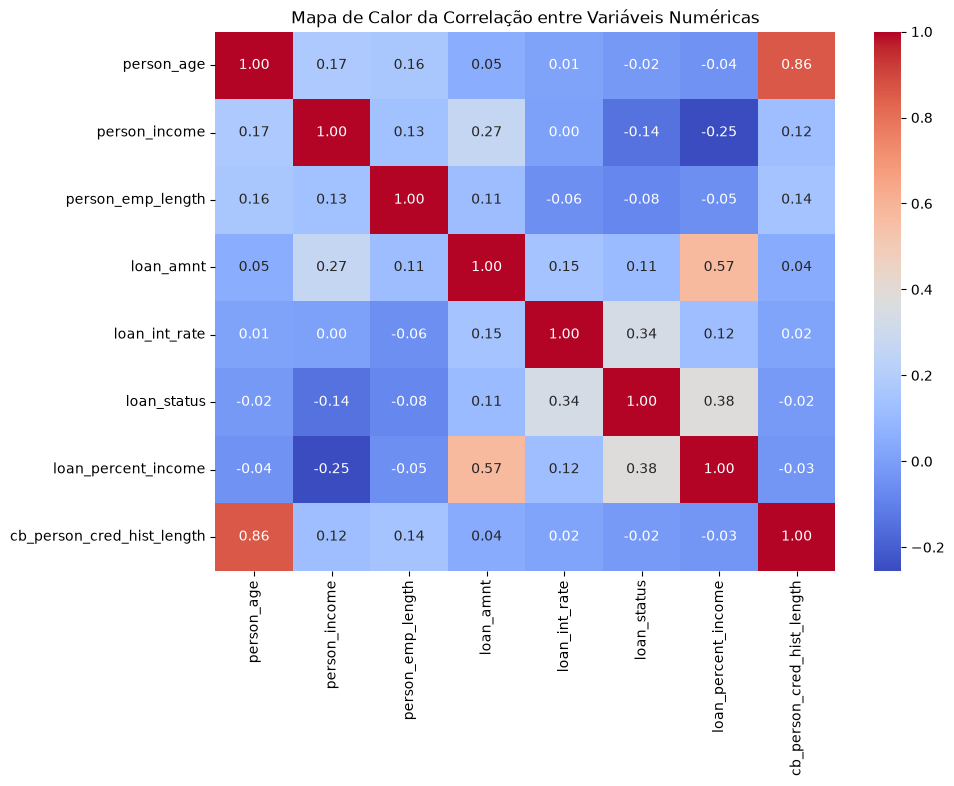

In [14]:
colunas_numericas = df.select_dtypes(include=["int64", "float64"])

correlacao = colunas_numericas.corr()

plt.figure(figsize=(10, 7))

sns.heatmap(correlacao, annot=True, fmt=".2f", cmap="coolwarm")

plt.title("Mapa de Calor da Correlação entre Variáveis Numéricas")

plt.show()

# 3. Tratamento e Limpeza dos Dados

Nesta etapa serão tratados registros duplicados, valores inconsistentes, dados ausentes e possíveis outliers identificados durante a análise exploratória.

As decisões de tratamento serão realizadas buscando preservar a maior quantidade possível de informações válidas da base.

## 3.1 Identificação e Remoção de Registros Duplicados

Registros duplicados podem introduzir redundância na base e influenciar indevidamente o treinamento dos modelos.

Por isso, será verificada a existência de linhas completamente duplicadas antes da modelagem.

In [15]:
duplicados = df.duplicated().sum()

print("Quantidade de registros duplicados:", duplicados)

Quantidade de registros duplicados: 165


### Análise dos Registros Duplicados

Foram identificados 165 registros completamente duplicados na base de dados.

Como essas linhas representam repetições exatas de registros já existentes, elas serão removidas para evitar redundância e impedir que determinadas observações tenham peso indevido durante o treinamento dos modelos.

In [16]:
df = df.drop_duplicates()

print("Quantidade de registros após remoção:", len(df))
print("Duplicados restantes:", df.duplicated().sum())

Quantidade de registros após remoção: 32416
Duplicados restantes: 0


## 3.2 Tratamento de Valores Inconsistentes

Durante a análise exploratória foram identificados registros em que o tempo de emprego (`person_emp_length`) é superior à idade do cliente (`person_age`).

Esse tipo de valor representa uma inconsistência lógica nos dados e não apenas um outlier estatístico.

Por isso, esses registros serão identificados e os valores inconsistentes de tempo de emprego serão convertidos para `NaN`, permitindo que sejam tratados posteriormente junto com os demais valores ausentes.

In [17]:
inconsistentes_emprego = df[df["person_emp_length"] > df["person_age"]][
    ["person_age", "person_emp_length"]
]

inconsistentes_emprego

,person_age,person_emp_length
0,22,123.0
210,21,123.0


In [18]:
print("Quantidade de registros inconsistentes:", len(inconsistentes_emprego))

Quantidade de registros inconsistentes: 2


### Tratamento dos Valores Inconsistentes

Foram identificados 2 registros em que o tempo de emprego é superior à idade do cliente.

Como esses valores são logicamente impossíveis, eles serão convertidos para `NaN` em vez de remover as linhas completas. Dessa forma, preservamos as demais informações válidas desses registros e tratamos apenas a variável inconsistente.

In [19]:
df.loc[df["person_emp_length"] > df["person_age"], "person_emp_length"] = np.nan

In [20]:
print(
    "Registro inconsistentes restantes:",
    (df["person_emp_length"] > df["person_age"]).sum(),
)

Registro inconsistentes restantes: 0


## 3.3 Tratamento de Valores Nulos

Após o tratamento das inconsistências, serão analisados novamente os valores ausentes da base.

A estratégia de imputação será escolhida de acordo com a distribuição das variáveis:

- A média pode ser utilizada quando os dados apresentam distribuição mais equilibrada e sem forte influência de outliers.
- A mediana é mais indicada quando existem valores extremos, pois é menos sensível a outliers.

In [21]:
df[["person_emp_length", "loan_int_rate"]].describe()

print("Valores nulos atuais:")

display(
    df[["person_emp_length", "loan_int_rate"]].isnull().sum()
)

Valores nulos atuais:


person_emp_length     889
loan_int_rate        3095
dtype: int64

### Estratégia de Imputação

Para a variável `person_emp_length`, será utilizada a mediana, pois a análise exploratória identificou valores extremos e uma distribuição mais sensível a outliers. A mediana é menos afetada por esses valores.

Para a variável `loan_int_rate`, será utilizada a média, pois os valores de média e mediana são muito próximos, indicando uma distribuição relativamente equilibrada.

In [22]:
mediana_emprego = df["person_emp_length"].median()
media_juros = df["loan_int_rate"].mean()

df["person_emp_length"] = df["person_emp_length"].fillna(mediana_emprego)
df["loan_int_rate"] = df["loan_int_rate"].fillna(media_juros)

In [23]:
print("Valore nulos restantes")
display(df[["person_emp_length", "loan_int_rate"]].isnull().sum())

Valore nulos restantes


person_emp_length    0
loan_int_rate        0
dtype: int64

## 3.4 Tratamento de Outliers

Após o tratamento dos valores inconsistentes e ausentes, será realizada uma nova análise das variáveis numéricas para identificar valores extremos que ainda possam afetar os modelos.

Os outliers não serão removidos automaticamente. Cada caso será avaliado considerando se o valor é plausível dentro do contexto do problema.

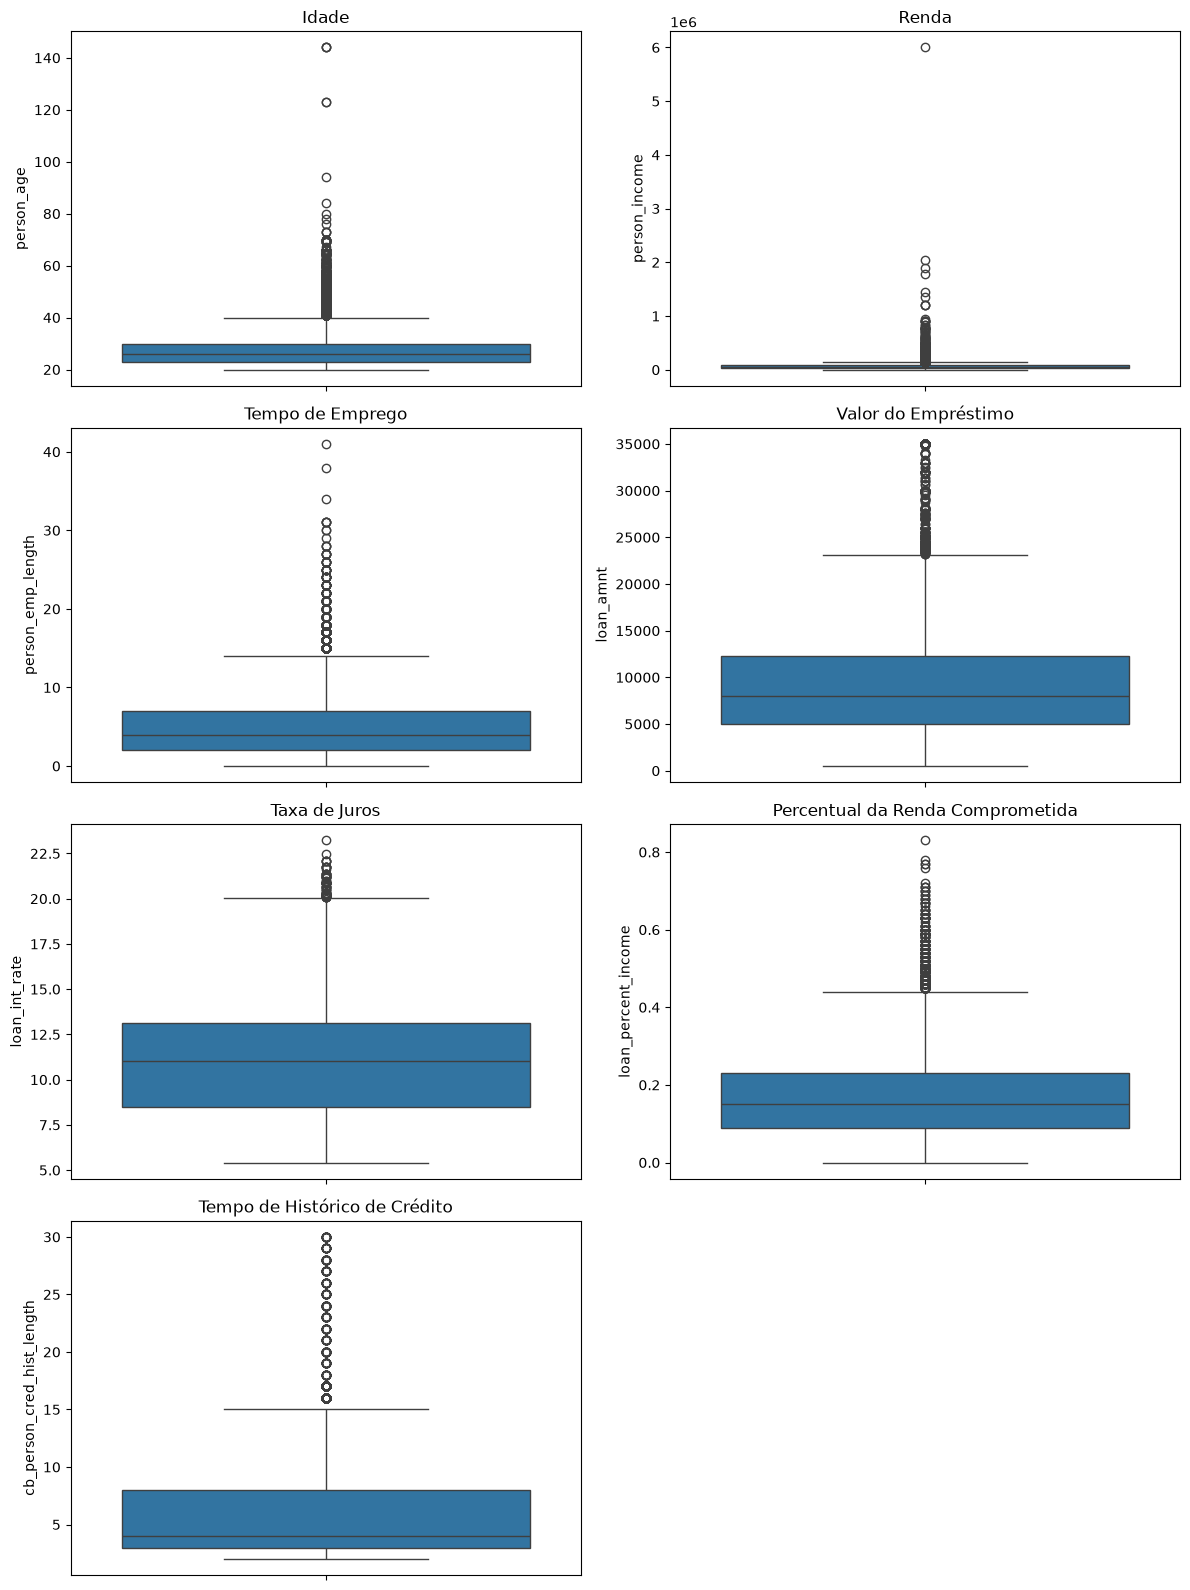

In [24]:
colunas_numericas = [
    "person_age",
    "person_income",
    "person_emp_length",
    "loan_amnt",
    "loan_int_rate",
    "loan_percent_income",
    "cb_person_cred_hist_length",
]

nomes_graficos = {
    "person_age": "Idade",
    "person_income": "Renda",
    "person_emp_length": "Tempo de Emprego",
    "loan_amnt": "Valor do Empréstimo",
    "loan_int_rate": "Taxa de Juros",
    "loan_percent_income": "Percentual da Renda Comprometida",
    "cb_person_cred_hist_length": "Tempo de Histórico de Crédito",
}

fig, axes = plt.subplots(4, 2, figsize=(12, 16))
axes = axes.flatten()

for i, coluna in enumerate(colunas_numericas):
    sns.boxplot(y=df[coluna], ax=axes[i])
    axes[i].set_title(nomes_graficos[coluna])

fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

In [25]:
df[colunas_numericas].agg(["min", "median", "mean", "max"]).T

,min,median,mean,max
person_age,20.00,26.000000,27.747008,144.00
person_income,4000.00,55000.000000,66091.640826,6000000.00
person_emp_length,0.00,4.000000,4.761538,41.00
loan_amnt,500.00,8000.000000,9593.845632,35000.00
loan_int_rate,5.42,11.017265,11.017265,23.22
loan_percent_income,0.00,0.150000,0.170250,0.83
cb_person_cred_hist_length,2.00,4.000000,5.811297,30.00


### Investigação de Valores Extremos

Os boxplots indicaram valores extremos principalmente nas variáveis `person_age` e `person_income`.

Antes de qualquer remoção ou alteração, esses registros serão analisados individualmente para verificar se representam valores plausíveis ou inconsistências nos dados.

In [26]:
print("Maiores idades:")

display(
    df.sort_values("person_age", ascending=False)[
        ["person_age", "person_income", "person_emp_length"]
    ].head(10)
)

print("\nMaiores rendas:")

display(
    df.sort_values("person_income", ascending=False)[
        ["person_age", "person_income", "loan_amnt", "loan_status"]
    ].head(10)
)

Maiores idades:


,person_age,person_income,person_emp_length
32297,144,6000000,12.0
81,144,250000,4.0
183,144,200000,4.0
747,123,78000,7.0
575,123,80004,2.0
32416,94,24000,1.0
32506,84,94800,2.0
32422,80,64000,7.0
32355,78,48000,41.0
32534,76,75000,23.0



Maiores rendas:


,person_age,person_income,loan_amnt,loan_status
32297,144,6000000,5000,0
30049,42,2039784,8450,0
32546,60,1900000,1500,0
32497,63,1782000,12025,0
31924,44,1440000,6400,0
31922,47,1362000,6600,0
17833,32,1200000,12000,0
29120,40,1200000,10000,0
29119,36,1200000,10000,0
17834,34,948000,2000,0


### Tratamento de Idades Inconsistentes

A investigação dos valores extremos revelou registros com idades de 123 e 144 anos.

Esses valores foram considerados inconsistentes para o contexto da base. Como representam uma quantidade muito pequena de registros em relação ao total da amostra, optou-se pela remoção completa dessas linhas, evitando a criação artificial de valores de idade por imputação.

Os demais clientes com idades elevadas, como 80, 84 e 94 anos, foram mantidos por representarem valores plausíveis.

In [27]:
idades_inconsistentes = df[df["person_age"] > 100]

print("Registros com idade superior a 100 anos:")

display(idades_inconsistentes)

print("Quantidade:", len(idades_inconsistentes))

Registros com idade superior a 100 anos:


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
81,144,250000,RENT,4.0,VENTURE,C,4800,13.570000,0,0.02,N,3
183,144,200000,MORTGAGE,4.0,EDUCATION,B,6000,11.860000,0,0.03,N,2
575,123,80004,RENT,2.0,EDUCATION,B,20400,10.250000,0,0.25,N,3
747,123,78000,RENT,7.0,VENTURE,B,20000,11.017265,0,0.26,N,4
32297,144,6000000,MORTGAGE,12.0,PERSONAL,C,5000,12.730000,0,0.00,N,25


Quantidade: 5


In [28]:
df = df[df["person_age"] <= 100].copy()

print(
    "Quantidade de registros após o tratamento:",
    len(df)
)

print(
    "Maior idade restante:",
    df["person_age"].max()
)

Quantidade de registros após o tratamento: 32411
Maior idade restante: 94



### 3.4.1 Análise de Rendas Extremas

Após o tratamento das idades inconsistentes, será realizada uma nova análise dos maiores valores de renda.

O objetivo é verificar se os valores extremos de `person_income` representam erros de preenchimento ou observações plausíveis que devem ser mantidas na base.

In [29]:
df.sort_values("person_income", ascending=False)[
    ["person_age", "person_income", "loan_amnt", "loan_status"]
].head(15)

,person_age,person_income,loan_amnt,loan_status
30049,42,2039784,8450,0
32546,60,1900000,1500,0
32497,63,1782000,12025,0
31924,44,1440000,6400,0
31922,47,1362000,6600,0
29120,40,1200000,10000,0
17833,32,1200000,12000,0
29119,36,1200000,10000,0
17834,34,948000,2000,0
29122,36,900000,6000,0


In [30]:
print("Maior renda:", df["person_income"].max())
print("Mediana da renda:", df["person_income"].median())
print("Média da renda:", df["person_income"].mean())

Maior renda: 2039784
Mediana da renda: 55000.0
Média da renda: 65897.95516954121


### Decisão sobre os Outliers de Renda

Após a remoção dos registros com idades inconsistentes, os maiores valores de renda foram reavaliados.

Embora a variável `person_income` apresente valores bastante elevados e distribuição assimétrica, não foram identificadas evidências suficientes de erro nesses registros.

Por esse motivo, os valores extremos de renda serão mantidos. A influência dessas diferenças de escala será tratada posteriormente no modelo KNN por meio de padronização com `StandardScaler`.

In [31]:
df["comprometimento_renda"] = (df["loan_amnt"] / df["person_income"]) * 100
print((df["person_income"] == 0).sum())


df[["loan_amnt", "person_income", "comprometimento_renda"]].head()

0


,loan_amnt,person_income,comprometimento_renda
0,35000,59000,59.322034
1,1000,9600,10.416667
2,5500,9600,57.291667
3,35000,65500,53.435115
4,35000,54400,64.338235


# 4. Feature Engineering

## 4.1 Criação da Variável `comprometimento_renda`

Nesta etapa foi criada uma nova variável numérica chamada `comprometimento_renda`, calculada a partir da relação entre o valor do empréstimo e a renda do cliente.

A fórmula utilizada foi:

`comprometimento_renda = (loan_amnt / person_income) * 100`

Essa variável representa, em percentual, o quanto o valor do empréstimo corresponde à renda do cliente.

Antes do cálculo, foi verificada a existência de valores iguais a zero em `person_income`, evitando divisões por zero.

In [32]:
print("Rendas iguais a zero:", (df["person_income"] == 0).sum())

df["comprometimento_renda"] = (df["loan_amnt"] / df["person_income"]) * 100

df[["loan_amnt", "person_income", "comprometimento_renda"]].head()

Rendas iguais a zero: 0


,loan_amnt,person_income,comprometimento_renda
0,35000,59000,59.322034
1,1000,9600,10.416667
2,5500,9600,57.291667
3,35000,65500,53.435115
4,35000,54400,64.338235


# 5. Preparação dos Dados para Modelagem

## 5.1 Encoding das Variáveis Categóricas

Nesta etapa, as variáveis categóricas serão convertidas para formato numérico.

Como os modelos de Machine Learning utilizados neste projeto não trabalham diretamente com valores textuais, será aplicado One-Hot Encoding nas colunas categóricas.

In [33]:
colunas_categoricas = df.select_dtypes(include=["object", "string"]).columns

print("Colunas categóricas: ")
print(colunas_categoricas.tolist())


Colunas categóricas: 
['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']


In [34]:
df_modelo = pd.get_dummies(
    df,
    columns=colunas_categoricas,
    drop_first=True
)
df_modelo.head()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,comprometimento_renda,person_home_ownership_OTHER,...,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_Y
0,22,59000,4.0,35000,16.02,1,0.59,3,59.322034,False,...,False,True,False,False,False,True,False,False,False,True
1,21,9600,5.0,1000,11.14,0,0.10,2,10.416667,False,...,False,False,False,True,False,False,False,False,False,False
2,25,9600,1.0,5500,12.87,1,0.57,3,57.291667,False,...,True,False,False,False,True,False,False,False,False,False
3,23,65500,4.0,35000,15.23,1,0.53,2,53.435115,False,...,True,False,False,False,True,False,False,False,False,False
4,24,54400,8.0,35000,14.27,1,0.55,4,64.338235,False,...,True,False,False,False,True,False,False,False,False,True


In [35]:
print("Dimensão original:", df.shape)
print("Dimensão após encoding", df_modelo.shape)

Dimensão original: (32411, 13)
Dimensão após encoding (32411, 24)


### Resultado do Encoding

Após a aplicação do One-Hot Encoding, a quantidade de registros permaneceu a mesma, com 32.411 linhas.

O número de colunas aumentou de 13 para 24, pois as variáveis categóricas foram transformadas em novas colunas numéricas binárias.

Essa transformação permite que os modelos de Machine Learning processem corretamente as variáveis originalmente textuais.

## 5.2 Separação entre Variáveis Preditoras e Variável Alvo

Nesta etapa, a variável alvo `loan_status` será separada das demais variáveis utilizadas para realizar as previsões.

As variáveis preditoras serão armazenadas em `X`, enquanto a variável alvo será armazenada em `y`.

In [36]:
X = df_modelo.drop(columns=["loan_status"])
y = df_modelo["loan_status"]

print("Dimensão de x: ", X.shape)
print("Dimensão de y: ", y.shape)

Dimensão de x:  (32411, 23)
Dimensão de y:  (32411,)


## 5.3 Divisão entre Dados de Treino e Teste

Os dados serão divididos em 80% para treino e 20% para teste.

Será utilizado o parâmetro `stratify=y` para preservar a proporção entre clientes adimplentes e inadimplentes nos dois conjuntos.

Essa etapa é importante para que tanto o treino quanto o teste mantenham uma distribuição de classes semelhante à base original.

In [37]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("X_train:", y_train.shape)
print("X_test:", y_test.shape)


X_train: (25928, 23)
X_test: (6483, 23)
X_train: (25928,)
X_test: (6483,)


In [38]:
print("Distribuição no treino:")
display(y_train.value_counts(normalize=True) * 100)

print("\nDistribuição no teste:")
display(y_test.value_counts(normalize=True) * 100)

Distribuição no treino:


loan_status
0    78.127893
1    21.872107
Name: proportion, dtype: float64


Distribuição no teste:


loan_status
0    78.12741
1    21.87259
Name: proportion, dtype: float64

## 5.4 Balanceamento das Classes

Como a variável alvo apresenta desbalanceamento, será aplicada uma técnica de reamostragem somente sobre o conjunto de treino.

Essa decisão evita vazamento de dados, pois o conjunto de teste deve permanecer com a distribuição original para representar um cenário mais realista de avaliação.

Neste projeto será utilizado o SMOTE para aumentar a quantidade de exemplos da classe minoritária no conjunto de treino.

In [39]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_bal, y_train_bal = smote.fit_resample(
    X_train,
    y_train
)

print("Distribuição antes do SMOTE:")
display(y_train.value_counts())

print("\nDistribuição depois do SMOTE:")
display(y_train_bal.value_counts())

Distribuição antes do SMOTE:


loan_status
0    20257
1     5671
Name: count, dtype: int64


Distribuição depois do SMOTE:


loan_status
0    20257
1    20257
Name: count, dtype: int64

In [40]:
print("Treino antes:", X_train.shape)
print("Treino balanceado:", X_train_bal.shape)

Treino antes: (25928, 23)
Treino balanceado: (40514, 23)


## 5.5 Escalonamento Seguro para o KNN

O modelo KNN utiliza medidas de distância entre os registros, sendo sensível à escala das variáveis.

Por esse motivo, será aplicado `StandardScaler` somente aos dados utilizados pelo KNN.

O ajuste do escalonador será realizado no conjunto de treino balanceado e, em seguida, a mesma transformação será aplicada ao conjunto de teste.

A Árvore de Decisão não utilizará os dados escalonados, pois esse algoritmo realiza divisões por critérios de decisão e não depende da escala das variáveis.

In [41]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_knn = scaler.fit_transform(X_train_bal)
X_test_knn = scaler.transform(X_test)

print("Treino escalonado:", X_train_knn.shape)
print("Teste escalonado:", X_test_knn.shape)

Treino escalonado: (40514, 23)
Teste escalonado: (6483, 23)


## 5.5 Escalonamento Seguro para o KNN

O modelo KNN utiliza medidas de distância entre os registros e, por isso, é sensível à escala das variáveis.

Será aplicado `StandardScaler` apenas aos dados utilizados pelo KNN.

O escalonador será ajustado somente no conjunto de treino balanceado e a mesma transformação será aplicada ao conjunto de teste, evitando vazamento de dados.

A Árvore de Decisão não utilizará os dados escalonados, pois esse algoritmo não depende da escala das variáveis.

In [42]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_knn = scaler.fit_transform(X_train_bal)
X_test_knn = scaler.transform(X_test)

print("Treino escalonado:", X_train_knn.shape)
print("Teste escalonado:", X_test_knn.shape)

Treino escalonado: (40514, 23)
Teste escalonado: (6483, 23)


# 6. Modelagem e Validação

## 6.1 Modelo KNN

Nesta etapa será treinado o algoritmo K-Nearest Neighbors (KNN).

Serão testados diferentes valores de `n_neighbors` para avaliar o comportamento do modelo em relação aos dados de treino e teste.

O objetivo é identificar uma configuração que apresente bom desempenho no conjunto de teste sem apresentar diferença excessiva em relação ao treino, reduzindo o risco de overfitting.

In [43]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

valores_k = [3, 5, 7, 9]

resultados_knn = []
for k  in valores_k :
    print(f"Testando K = {k}...")
    modelo_knn = KNeighborsClassifier(n_neighbors=k)
    modelo_knn.fit(X_train_knn, y_train_bal)
    
    pred_train = modelo_knn.predict(X_train_knn)
    pred_test = modelo_knn.predict(X_test_knn)
    
    acc_train = accuracy_score(y_train_bal,pred_train)
    acc_test = accuracy_score(y_test, pred_test)
    
    resultados_knn.append({
        "K": k,
        "Acurácia Treino": acc_train,
        "Acurácia Teste": acc_test
    })
print("\nResultados:")
resultados_knn_df = pd.DataFrame(resultados_knn)
display(resultados_knn_df)

Testando K = 3...
Testando K = 5...
Testando K = 7...
Testando K = 9...

Resultados:


,K,Acurácia Treino,Acurácia Teste
0,3,0.951177,0.873824
1,5,0.938861,0.882616
2,7,0.932517,0.888478
3,9,0.927852,0.893568


### 6.1.1 Análise dos Valores de K

Os resultados mostram que valores menores de `K` apresentaram maior desempenho no conjunto de treino, porém com uma diferença maior em relação ao conjunto de teste.

O modelo com `K = 3` alcançou aproximadamente 95,12% de acurácia no treino e 87,38% no teste, indicando maior tendência ao overfitting.

Conforme o valor de `K` aumentou, a acurácia de treino diminuiu e o desempenho no teste melhorou.

Entre os valores avaliados, `K = 9` apresentou aproximadamente 92,79% de acurácia no treino e 89,36% no teste, resultando na menor diferença entre os dois conjuntos e na maior acurácia de teste entre as configurações analisadas.

Esses resultados indicam que o aumento de `K` reduziu a tendência de o modelo memorizar excessivamente os dados de treino e melhorou sua capacidade de generalização.

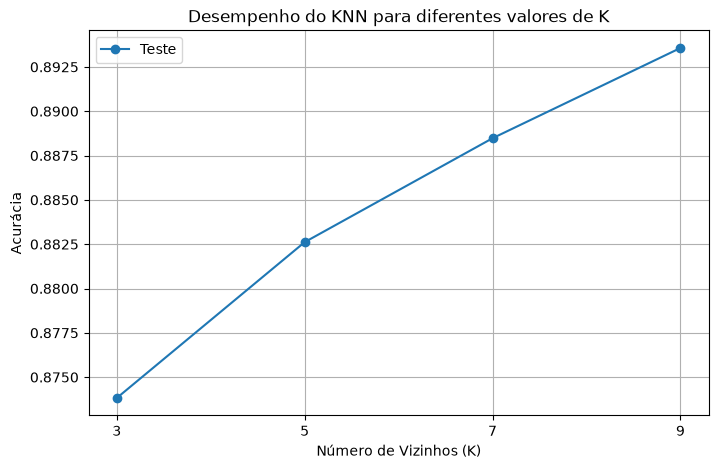

In [44]:
plt.figure(figsize=(8, 5))
plt.plot(
    resultados_knn_df["K"],
    resultados_knn_df["Acurácia Teste"],
    marker = "o",
    label = "Teste"
)

plt.title("Desempenho do KNN para diferentes valores de K")
plt.xlabel("Número de Vizinhos (K)")
plt.ylabel("Acurácia")
plt.xticks(valores_k)
plt.legend()
plt.grid(True)

plt.show()

## 6.2 Árvore de Decisão

Nesta etapa será treinado o modelo de Árvore de Decisão.

Diferentemente do KNN, a Árvore de Decisão não necessita de escalonamento das variáveis, pois realiza divisões com base em critérios de decisão e não utiliza distância entre os registros.

Serão testados diferentes valores de `max_depth` para avaliar o impacto da complexidade do modelo e identificar possíveis sinais de overfitting.

In [45]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

profundidades = [3, 5, 7, None]

resultados_arvore = []

for profundidade in profundidades:
    print(f"Testando max_depth = {profundidade}...")
    
    modelo_arvore = DecisionTreeClassifier(
        max_depth=profundidade,
        random_state=42
    )
    
    modelo_arvore.fit(X_train_bal, pred_train)
    
    pred_train = modelo_arvore.predict(X_train_bal)
    pred_test = modelo_arvore.predict(X_test)
    
    acc_train = accuracy_score(y_train_bal, pred_train)
    acc_test = accuracy_score(y_test, pred_test)
    
    resultados_arvore.append({
        "max_depth": profundidade,
        "Acurácia Treino": acc_train,
        "Acurácia Teste": acc_test
    })
    
    resultados_arvore_df = pd.DataFrame(resultados_arvore)
    display(resultados_arvore_df)
    

Testando max_depth = 3...


,max_depth,Acurácia Treino,Acurácia Teste
0,3,0.848324,0.883233


Testando max_depth = 5...


,max_depth,Acurácia Treino,Acurácia Teste
0,3,0.848324,0.883233
1,5,0.848324,0.883233


Testando max_depth = 7...


,max_depth,Acurácia Treino,Acurácia Teste
0,3,0.848324,0.883233
1,5,0.848324,0.883233
2,7,0.848324,0.883233


Testando max_depth = None...


,max_depth,Acurácia Treino,Acurácia Teste
0,3.0,0.848324,0.883233
1,5.0,0.848324,0.883233
2,7.0,0.848324,0.883233
3,NaN,0.848324,0.883233


## 6.2 Árvore de Decisão

A Árvore de Decisão não necessita de escalonamento das variáveis.

Serão testados diferentes valores de `max_depth` para analisar a complexidade do modelo e possíveis sinais de overfitting.

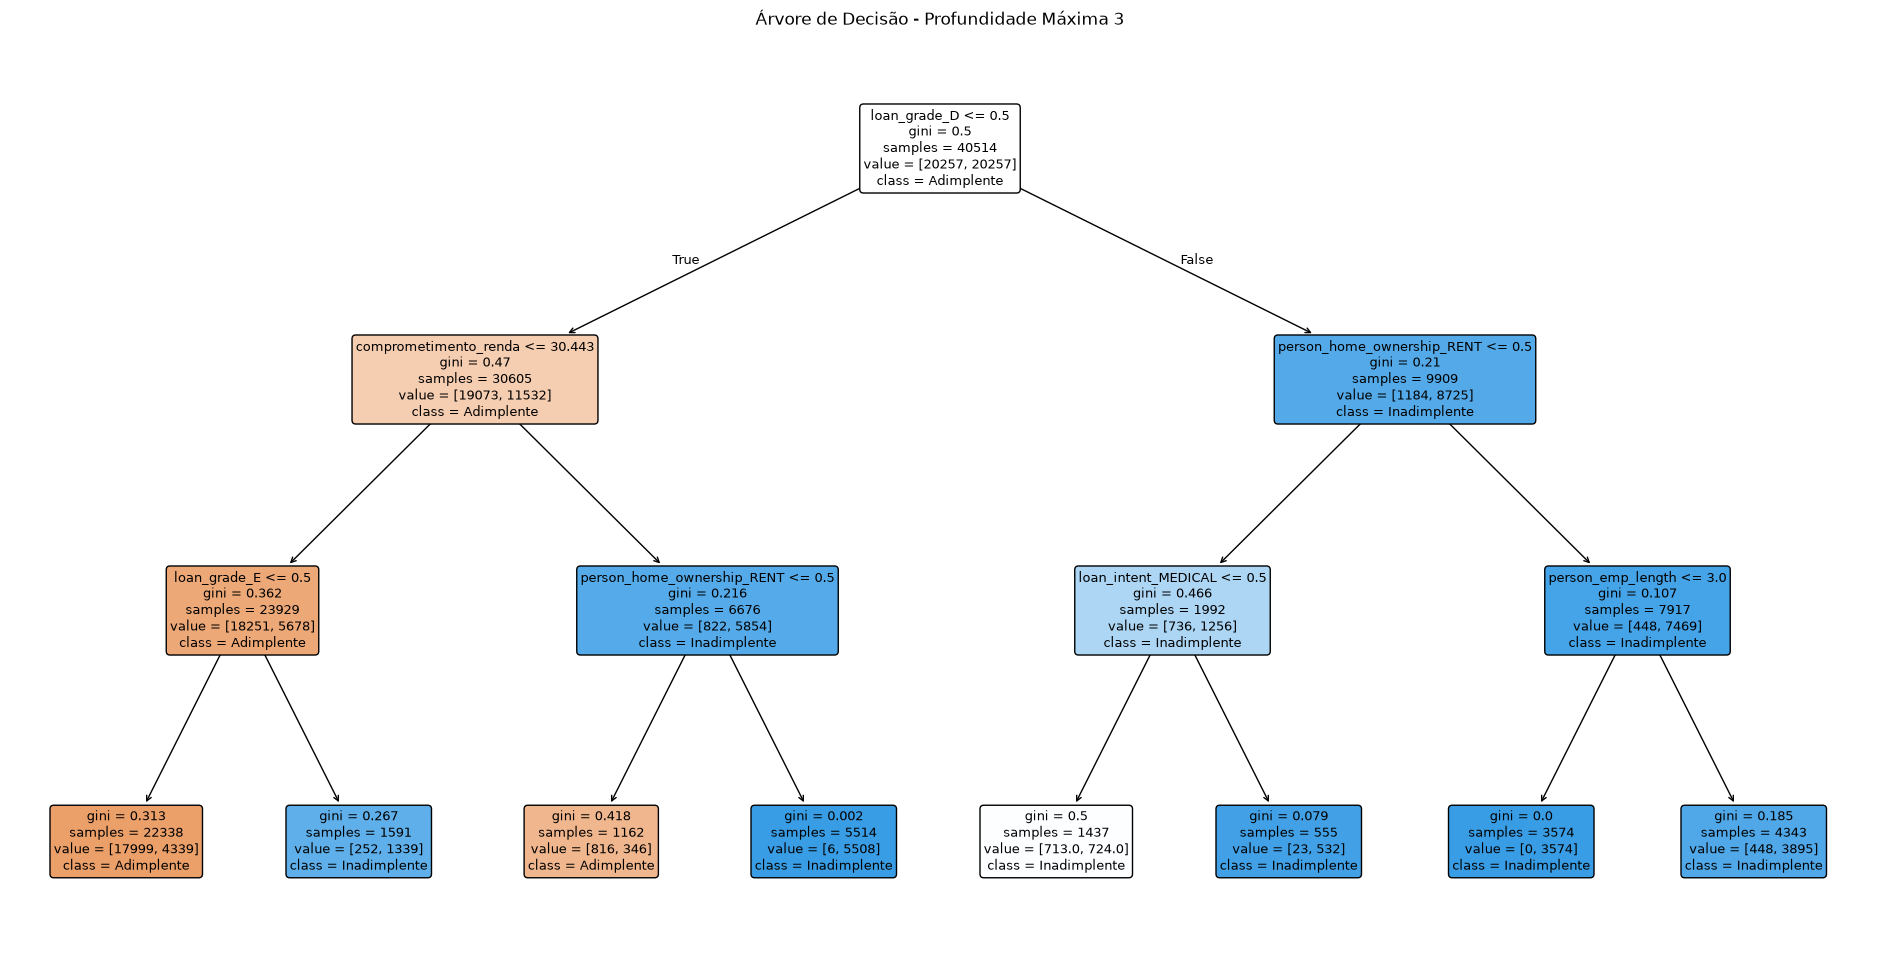

In [46]:
from sklearn.tree import plot_tree

arvore_visual = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

arvore_visual.fit(X_train_bal, y_train_bal)

plt.figure(figsize=(24, 12))

plot_tree(
    arvore_visual,
    feature_names=X_train_bal.columns,
    class_names=["Adimplente", "Inadimplente"],
    filled=True,
    rounded=True,
    fontsize=9
)

plt.title("Árvore de Decisão - Profundidade Máxima 3")

plt.show()

### 6.2.2 Análise de Overfitting da Árvore de Decisão

Nesta etapa serão comparadas as acurácias obtidas nos conjuntos de treino e teste para diferentes valores de `max_depth`.

O objetivo é identificar em qual ponto o aumento da complexidade da árvore deixa de melhorar a capacidade de generalização e passa a favorecer excessivamente o desempenho no conjunto de treino.

In [47]:
profundidades = [3, 5, 7, None]

resultados_arvore = []

for profundidade in profundidades:
    
    modelo_arvore = DecisionTreeClassifier(
        max_depth=profundidade,
        random_state=42
    )
    
    modelo_arvore.fit(
        X_train_bal,
        y_train_bal
    )
    
    pred_train_arvore = modelo_arvore.predict(
        X_train_bal
    )
    
    pred_test_arvore = modelo_arvore.predict(
        X_test
    )
    
    acc_train_arvore = accuracy_score(
        y_train_bal,
        pred_train_arvore
    )
    
    acc_test_arvore = accuracy_score(
        y_test,
        pred_test_arvore
    )
    
    diferenca = acc_train_arvore - acc_test_arvore
    
    resultados_arvore.append({
        "max_depth": "Sem limite" if profundidade is None else profundidade,
        "Acurácia Treino": acc_train_arvore,
        "Acurácia Teste": acc_test_arvore,
        "Diferença": diferenca
    })

resultados_arvore_df = pd.DataFrame(
    resultados_arvore
)

display(resultados_arvore_df)

,max_depth,Acurácia Treino,Acurácia Teste,Diferença
0,3,0.848768,0.865957,-0.017189
1,5,0.886805,0.890791,-0.003987
2,7,0.905095,0.905291,-0.000196
3,Sem limite,1.000000,0.879685,0.120315


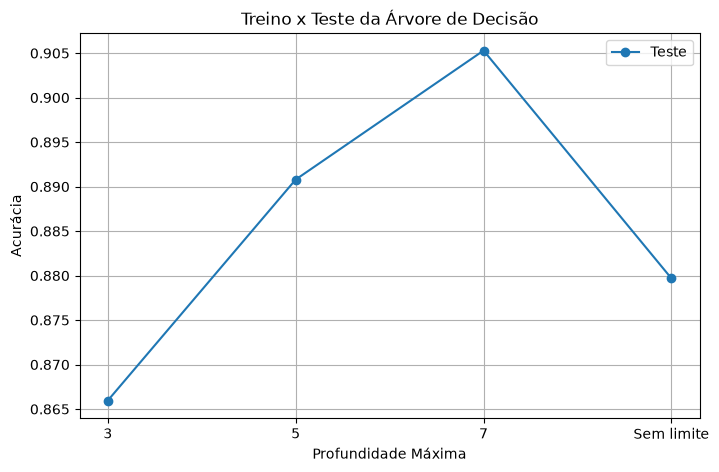

In [48]:
labels_profundidade = [
    str(valor)
    for valor in resultados_arvore_df["max_depth"]
]

posicoes = range(
    len(labels_profundidade)
)

plt.figure(figsize=(8,5))

plt.plot(
    posicoes,
    resultados_arvore_df["Acurácia Teste"],
    marker="o",
    label="Teste"
    
    
    
)

plt.xticks(
    posicoes,
    labels_profundidade

)
plt.title(
    "Treino x Teste da Árvore de Decisão"
)
plt.xlabel(
    "Profundidade Máxima"
)
plt.ylabel(
    "Acurácia"
)
plt.legend()
plt.grid(True)

plt.show()


In [49]:
display(resultados_arvore_df)

,max_depth,Acurácia Treino,Acurácia Teste,Diferença
0,3,0.848768,0.865957,-0.017189
1,5,0.886805,0.890791,-0.003987
2,7,0.905095,0.905291,-0.000196
3,Sem limite,1.000000,0.879685,0.120315


### 6.2.2 Análise de Overfitting da Árvore de Decisão

Os resultados mostram que o aumento da profundidade melhora o desempenho da Árvore de Decisão até determinado ponto.

Com `max_depth = 3`, o modelo apresentou aproximadamente 84,88% de acurácia no treino e 86,60% no teste.

Com profundidade 5, os resultados aumentaram para aproximadamente 88,68% no treino e 89,08% no teste.

A configuração `max_depth = 7` apresentou o melhor equilíbrio entre desempenho e generalização, com aproximadamente 90,51% de acurácia no treino e 90,53% no teste.

Quando a profundidade foi deixada sem limite, a árvore atingiu 100% de acurácia no conjunto de treino, mas caiu para aproximadamente 87,97% no teste. Essa diferença evidencia um forte caso de overfitting, pois o modelo passou a se ajustar excessivamente aos dados de treinamento e perdeu capacidade de generalização.

Dessa forma, `max_depth = 7` foi selecionado como a melhor configuração da Árvore de Decisão entre os valores avaliados.

# 7. Avaliação dos Modelos

Nesta etapa serão avaliadas as melhores configurações selecionadas para o KNN e para a Árvore de Decisão.

Serão analisados:

- Classification Report;
- Matriz de Confusão;
- Falsos Positivos;
- Falsos Negativos;
- Impacto dos erros sob a ótica do negócio.

In [50]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Melhor KNN
knn_final = KNeighborsClassifier(
    n_neighbors=9
)

knn_final.fit(
    X_train_knn,
    y_train_bal
)

pred_knn_final = knn_final.predict(
    X_test_knn
)

# Melhor Árvore
arvore_final = DecisionTreeClassifier(
    max_depth=7,
    random_state=42
)

arvore_final.fit(
    X_train_bal,
    y_train_bal
)

pred_arvore_final = arvore_final.predict(
    X_test
)

## 7.1 Classification Report

O Classification Report permite avaliar o desempenho dos modelos por meio das métricas de precisão, recall, F1-score e suporte para cada classe.

In [51]:
print("CLASSIFICATION REPORT - KNN")
print(
    classification_report(
        y_test,
        pred_knn_final,
        target_names=[
            "Adimplente",
            "Inadimplente"
        ]
    )
)

print("\nCLASSIFICATION REPORT - ÁRVORE DE DECISÃO")
print(
    classification_report(
        y_test,
        pred_arvore_final,
        target_names=[
            "Adimplente",
            "Inadimplente"
        ]
    )
)

CLASSIFICATION REPORT - KNN
              precision    recall  f1-score   support

  Adimplente       0.91      0.95      0.93      5065
Inadimplente       0.81      0.68      0.74      1418

    accuracy                           0.89      6483
   macro avg       0.86      0.82      0.83      6483
weighted avg       0.89      0.89      0.89      6483


CLASSIFICATION REPORT - ÁRVORE DE DECISÃO
              precision    recall  f1-score   support

  Adimplente       0.92      0.97      0.94      5065
Inadimplente       0.86      0.68      0.76      1418

    accuracy                           0.91      6483
   macro avg       0.89      0.82      0.85      6483
weighted avg       0.90      0.91      0.90      6483



### Análise dos Classification Reports

A Árvore de Decisão apresentou desempenho geral superior ao KNN, com acurácia aproximada de 91%, contra 89% do KNN.

Para a classe de clientes inadimplentes, a Árvore apresentou precision de 0,86, superior aos 0,81 obtidos pelo KNN. Isso indica que, quando a Árvore classifica um cliente como inadimplente, sua previsão tende a ser mais confiável.

Entretanto, os dois modelos apresentaram recall de aproximadamente 0,68 para a classe inadimplente. Isso significa que ambos identificaram cerca de 68% dos clientes inadimplentes presentes no conjunto de teste.

Esse resultado merece atenção, pois os inadimplentes não identificados pelo modelo correspondem a Falsos Negativos, situação em que um cliente de risco é classificado como seguro.

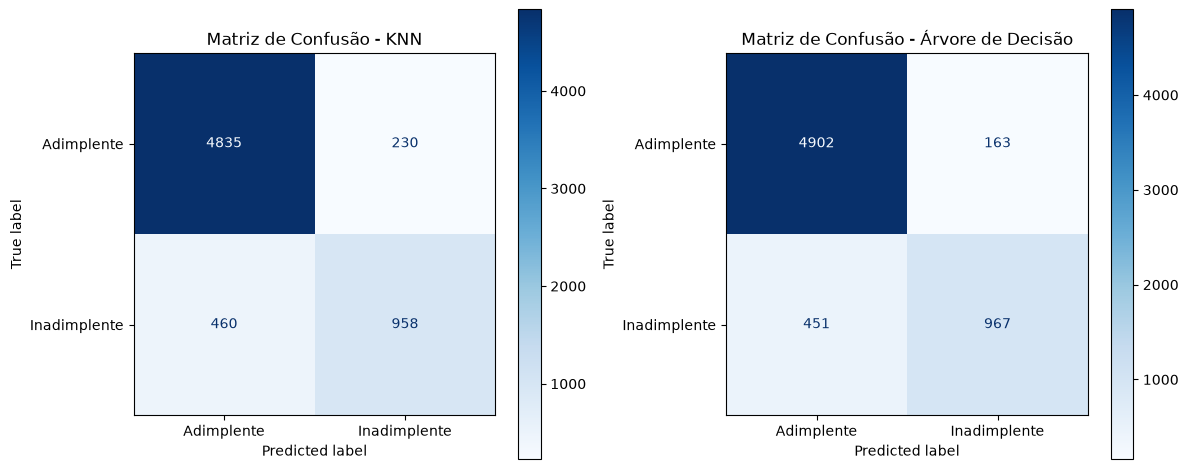

In [52]:
## 7.2 Matrizes de Confusão

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred_knn_final,
    display_labels=["Adimplente", "Inadimplente"],
    cmap="Blues",
    ax=axes[0]
)

axes[0].set_title("Matriz de Confusão - KNN")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred_arvore_final,
    display_labels=["Adimplente", "Inadimplente"],
    cmap="Blues",
    ax=axes[1]
)

axes[1].set_title("Matriz de Confusão - Árvore de Decisão")

plt.tight_layout()
plt.show()

## 7.2 Análise das Matrizes de Confusão

As matrizes de confusão permitem observar não apenas os acertos dos modelos, mas também os tipos de erro cometidos.

No KNN foram observados:

- 4.835 clientes adimplentes classificados corretamente;
- 230 Falsos Positivos;
- 460 Falsos Negativos;
- 958 clientes inadimplentes classificados corretamente.

Na Árvore de Decisão foram observados:

- 4.902 clientes adimplentes classificados corretamente;
- 163 Falsos Positivos;
- 451 Falsos Negativos;
- 967 clientes inadimplentes classificados corretamente.

Comparando os modelos, a Árvore de Decisão apresentou menor quantidade de Falsos Positivos e também menor quantidade de Falsos Negativos.

## 7.3 Impacto de Falsos Positivos e Falsos Negativos

No contexto de risco de crédito, um Falso Positivo ocorre quando um cliente que pagaria corretamente é classificado como inadimplente.

Esse erro pode fazer o banco negar crédito a um bom cliente, causando perda de oportunidade de receita e possível insatisfação do consumidor.

Já o Falso Negativo ocorre quando um cliente realmente inadimplente é classificado como adimplente.

Esse tipo de erro tende a apresentar impacto financeiro mais grave, pois pode levar o banco a conceder crédito a um cliente com maior risco de não pagamento, resultando em perdas financeiras diretas.

Por esse motivo, além da acurácia geral, é especialmente importante observar a capacidade dos modelos de reduzir Falsos Negativos.

## 7.4 Comparação Final entre os Modelos

A comparação final mostra que a Árvore de Decisão apresentou desempenho superior ao KNN na maior parte das métricas avaliadas.

O KNN, com `K = 9`, apresentou acurácia aproximada de 89,36% no conjunto de teste.

A Árvore de Decisão, com `max_depth = 7`, apresentou acurácia aproximada de 90,53%.

Além da maior acurácia, a Árvore também apresentou melhor precision para a classe inadimplente e produziu menos Falsos Positivos e menos Falsos Negativos.

Por outro lado, os dois modelos apresentaram recall semelhante para a classe inadimplente, em torno de 68%, indicando que ainda existe espaço para melhoria na identificação de clientes de maior risco.

# 8. Veredito de Negócio

Considerando os resultados obtidos, a Árvore de Decisão com `max_depth = 7` foi o modelo que apresentou o melhor equilíbrio entre desempenho e capacidade de generalização entre as configurações avaliadas.

Ela apresentou aproximadamente 90,53% de acurácia no conjunto de teste, superando o KNN com `K = 9`, que obteve aproximadamente 89,36%.

A Árvore também apresentou menor quantidade de Falsos Positivos e Falsos Negativos.

No contexto de risco de crédito, os Falsos Negativos merecem atenção especial, pois representam clientes inadimplentes classificados como seguros. Esse tipo de erro pode gerar perdas financeiras diretas caso o banco conceda crédito a clientes com maior risco de não pagamento.

Por isso, entre os dois modelos avaliados neste projeto, a Árvore de Decisão com profundidade máxima igual a 7 foi selecionada como a configuração mais adequada para este cenário.

Apesar do resultado superior, o recall de aproximadamente 68% para a classe inadimplente mostra que o modelo ainda não identifica todos os clientes de risco. Em um ambiente real, seria recomendável continuar o processo de otimização e avaliar outras técnicas antes de uma implantação definitiva em produção.